# P08: Applications & Modern Python

A figure is an argument. Here we build two staples of systems neuroscience -- a
spike raster and a peri-stimulus time histogram (PSTH) -- and a simple bar-with-
error-bars summary. Along the way we cover the modern object-oriented plotting API
and the surprisingly large number of ways a plausible-looking figure can mislead.

## Raster + PSTH from simulated spikes

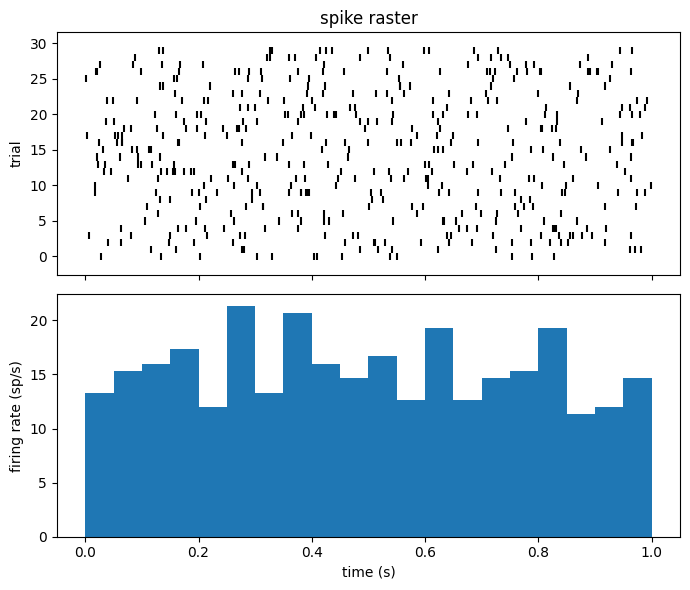

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)

# simulate spike times (in seconds) across 30 trials, stimulus onset at t=0
n_trials = 30
spike_times = [rng.uniform(0, 1, rng.poisson(15)) for _ in range(n_trials)]

# the modern, recommended interface: create the figure and axes explicitly
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

# raster: one row of ticks per trial
ax1.eventplot(spike_times, colors="black")
ax1.set_ylabel("trial")
ax1.set_title("spike raster")

# PSTH: bin all spikes, then convert counts to a firing rate
all_spikes = np.concatenate(spike_times)
bin_width = 0.05                                   # seconds
bins = np.arange(0, 1 + bin_width, bin_width)
counts, edges = np.histogram(all_spikes, bins=bins)
rate = counts / (n_trials * bin_width)             # spikes per second
ax2.bar(edges[:-1], rate, width=bin_width, align="edge")
ax2.set_xlabel("time (s)")
ax2.set_ylabel("firing rate (sp/s)")

fig.tight_layout()

:::{admonition} Human check — the PSTH bin width is a hidden analysis choice
:class: warning
`bin_width` is not cosmetic: too wide and you smear away real temporal structure,
too narrow and you see noise. Nothing in the code warns you. Convert counts to a
*rate* (divide by trials and bin width) so the y-axis is interpretable, and report
the bin width in your methods. An AI given "make a PSTH" will pick a bin width for
you -- that choice is yours to own.
:::

## A bar chart with error bars

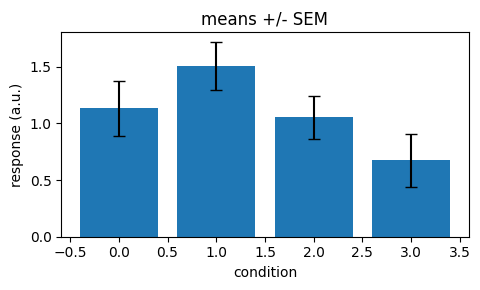

In [2]:
rng = np.random.default_rng(2)
data = rng.normal(0, 1, (20, 4)) + np.array([1.0, 1.2, 0.9, 1.1])   # 20 subjects x 4 conditions

means = data.mean(axis=0)
# ddof=1 -> SAMPLE standard deviation; then divide by sqrt(N) for the SEM
sem = data.std(axis=0, ddof=1) / np.sqrt(data.shape[0])

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(range(4), means, yerr=sem, capsize=4)
ax.set_xlabel("condition")
ax.set_ylabel("response (a.u.)")
ax.set_title("means +/- SEM")
fig.tight_layout()

:::{admonition} Human check — error bars and color maps lie if you let them
:class: warning
Several plotting choices are technically valid and scientifically misleading:

* **What does the error bar mean?** SD, SEM, and 95% CI differ by large factors. An
  AI may emit `yerr=data.std(0)` (population SD, `ddof=0`) when you meant the SEM.
  State which you used.
* **`ddof`.** `np.std` defaults to `ddof=0` (population). Sample statistics want
  `ddof=1`. The plot looks identical; the inference does not.
* **Within-subject designs** need a within-subject error bar (e.g.
  Cousineau-Morey); plain across-subject SEM overstates uncertainty for the
  comparison you care about.
* **Color maps.** Avoid `jet`/`rainbow` for brain maps -- they create illusory
  edges. Use a perceptually uniform map like `viridis`.
* **Truncated y-axes** exaggerate tiny effects; a bar chart hides the distribution
  (consider also plotting the individual points).
:::

:::{admonition} Modern Python
:class: tip
Prefer the **object-oriented API** -- `fig, ax = plt.subplots()` and then
`ax.plot(...)` -- over the older `plt.plot(...)` state-machine style. It makes
multi-panel figures (the norm in papers) far easier to manage, and it is what
current matplotlib documentation uses throughout.
:::